# 05 — P-Median-Based Capacity Allocation MILP

This notebook implements **Phase 3 (allocation)** and **Phase 4 (scenario evaluation)** of the
revised dissertation outline.

The model is formulated as a **Mixed-Integer Linear Program (MILP)**:

- \(x_j\in\mathbb Z_{\ge 0}\): integer additional charging-capacity units allocated to LSOA \(j\);
- \(y_{ij}\in[0,1]\): continuous share of demand at LSOA \(i\) assigned to LSOA \(j\);
- \(z_i\in[0,1]\): continuous share of LSOA \(i\)'s own demand that is **not served** by any
  allocation node.

The earlier destination-side slack version (\(s_j\), unpenalised or penalised) let the solver
report a short "assigned" distance for demand that was never actually served, because \(y_{ij}\)
summed to 1 regardless of whether real capacity backed the assignment. This revision instead
records unmet demand at its **origin** and solves the model in two steps, so \(y_{ij}\) only ever
represents demand that genuinely fits within capacity:

**Step 1 — feasibility:**
\[
\min \sum_i D_i^{(\alpha)} z_i
\quad\text{s.t. } \sum_j y_{ij} + z_i = 1,\ \ \sum_i D_i^{(\alpha)} y_{ij} \le K(e_j+x_j),\ \ \sum_j x_j = p.
\]
This establishes \(Z^*_{\alpha,p}\), the minimum \(D_i^{(\alpha)}\)-weighted unmet demand
achievable under the given \(\alpha\), \(p\), \(K\), \(U_j\).

**Step 2 — p-median (unchanged objective):**
\[
\min \sum_i\sum_j D_i^{(\alpha)} d_{ij} y_{ij}
\quad\text{s.t. the same constraints, plus } \sum_i D_i^{(\alpha)} z_i \le Z^*_{\alpha,p}.
\]
Step 2 **is** the p-median objective — Step 1 only fixes how much demand is unavoidably unserved
before Step 2 picks the distance-minimising assignment among the solutions that already achieve
that minimum. No penalty weight needs to be tuned.

**Important:** M1–M4 are calculated from Step 2's distance objective and \(\bar d_i^{served}\)
(mean assignment distance among *served* demand only), not from \(z_i\). Unmet demand (\(z_i\))
is reported as its own diagnostic, separately from the four core metrics.


## 0. Setup and execution controls

Set the `DISSERTATION_BASE` environment variable when running the project from a different folder. Start with the smoke tests, inspect their diagnostics, and then enable the full core grid.


In [ ]:
from pathlib import Path
import os
import re
import time
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import spearmanr

try:
    import pulp
except ImportError as exc:
    raise ImportError(
        "PuLP is required. Install it in the active environment with: pip install pulp"
    ) from exc

BASE = Path(os.environ.get(
    "DISSERTATION_BASE",
    "/Users/alexia/Documents/CASA/Dissertation",
))
PROCESSED_DIR = BASE / "05_processed"
OUTPUT_DIR = BASE / "06_outputs"
FIGURES_DIR = OUTPUT_DIR / "figures" / "05_p_median"
TABLES_DIR = OUTPUT_DIR / "tables" / "05_p_median"
SOLVER_LOG_DIR = OUTPUT_DIR / "solver_logs"

for directory in [PROCESSED_DIR, OUTPUT_DIR, FIGURES_DIR, TABLES_DIR, SOLVER_LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

PATHS = {
    "demand": PROCESSED_DIR / "demand_london.csv",
    "boundaries": BASE / "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp",
}
for name, path in PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {name}: {path}")

# Core scenario design from the outline.
SCENARIOS = {
    "A": {"alpha": 0.0, "demand_col": "D_A"},
    "B": {"alpha": 0.1, "demand_col": "D_B"},
    "C": {"alpha": 0.3, "demand_col": "D_C"},
    "D": {"alpha": 0.5, "demand_col": "D_D"},
}
P_VALUES = [2_000, 5_000, 8_000]
REFERENCE_SCENARIO = "C"
P_REF = 5_000
U_MAX = 150
K_NEIGHBOURS = 40
OPTIONAL_SERVICE_RADIUS_M = 800.0

# Run controls.
RUN_SMOKE_TEST = True
RUN_FULL_GRID = True
RUN_SENSITIVITY = True
RUN_EXTENDED_P_SENSITIVITY = True
SAVE_POSITIVE_ASSIGNMENTS = True

# Smoke tests deliberately include a tighter p and the reference p.
SMOKE_TESTS = [("A", 2_000), ("C", 2_000), ("A", 5_000), ("C", 5_000)]

# Optional extended investment curve for Results/Discussion.
EXTENDED_P_VALUES = [1_000, 2_000, 3_500, 5_000, 6_500, 8_000, 10_000]
EXTENDED_P_SCENARIOS = ["A", "C"]

DEFAULT_TIME_LIMIT_SECONDS = 300
RELATIVE_GAP_TARGET = 0.02
CBC_MESSAGES = True

print("Using project base:", BASE)
print("PuLP version:", pulp.__version__)


Using project base: /Users/alexia/Documents/CASA/Dissertation
PuLP version: 3.3.2


## 1. Build the common LSOA demand/allocation table \((I=J)\)

All Greater London LSOAs are used both as demand nodes and as candidate allocation nodes. Euclidean centroid distances are calculated in EPSG:27700.


In [2]:
def require_columns(df: pd.DataFrame, required: list[str], name: str) -> None:
    missing = [column for column in required if column not in df.columns]
    if missing:
        raise KeyError(f"{name}: missing required columns {missing}")


demand = pd.read_csv(PATHS["demand"])
require_columns(
    demand,
    [
        "lsoa_code", "e_i", "D_A", "D_B", "D_C", "D_D", "IMD_i",
        # "london_income_decile" 不在这里检查——这一列由本notebook自己现算，
        # 不是要求 demand_london.csv 里必须已经带着它
    ],
    "demand_london.csv",
)

# London-specific deprivation deciles (1 = most deprived, 10 = least deprived)
# rank(method="first") 打散并列值，保证10组精确均分（跟02调试时确认过的做法一致）
income_rank = demand["IMD_i"].rank(method="first", ascending=False)
demand["london_income_decile"] = pd.qcut(income_rank, 10, labels=False) + 1

decile_check = demand.groupby("london_income_decile")["IMD_i"].agg(["count", "min", "max"])
assert demand["london_income_decile"].between(1, 10).all()
assert decile_check["count"].between(499, 500).all(), "Decile groups should each hold exactly 499 or 500 LSOAs."

boundaries = gpd.read_file(PATHS["boundaries"])
if boundaries.crs is None:
    boundaries = boundaries.set_crs(epsg=27700)
elif boundaries.crs.to_epsg() != 27700:
    boundaries = boundaries.to_crs(epsg=27700)

lsoa_geometry = (
    boundaries.loc[boundaries["LSOA21CD"].isin(demand["lsoa_code"])]
    .rename(columns={"LSOA21CD": "lsoa_code"})
    [["lsoa_code", "geometry"]]
    .copy()
)
lsoa_geometry["centroid"] = lsoa_geometry.geometry.centroid
lsoa_geometry["cx"] = lsoa_geometry["centroid"].x
lsoa_geometry["cy"] = lsoa_geometry["centroid"].y

lsoa_master = (
    demand.merge(
        lsoa_geometry[["lsoa_code", "cx", "cy"]],
        on="lsoa_code",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("lsoa_code")
    .reset_index(drop=True)
)

if len(lsoa_master) != len(demand):
    raise ValueError("Some demand LSOAs did not match the boundary file.")
if lsoa_master["lsoa_code"].duplicated().any():
    raise ValueError("lsoa_master is not one row per LSOA.")
if lsoa_master[["D_A", "D_B", "D_C", "D_D", "e_i", "cx", "cy"]].isna().any().any():
    raise ValueError("Missing values found in required model inputs.")
if not lsoa_master["london_income_decile"].between(1, 10).all():
    raise ValueError("london_income_decile must contain values from 1 to 10.")

n = len(lsoa_master)
coords = lsoa_master[["cx", "cy"]].to_numpy(dtype=float)
D0 = lsoa_master["D_A"].to_numpy(dtype=float)
e_existing = lsoa_master["e_i"].to_numpy(dtype=float)
K0 = D0.sum() / (e_existing.sum() + P_REF)

print(f"Demand nodes |I|: {n:,}")
print(f"Candidate allocation nodes |J|: {n:,}")
print(f"Full pairwise assignment count: {n*n:,}")
print(f"Existing on-street locations: {e_existing.sum():,.0f}")
print(f"K0: {K0:.6f}")


Demand nodes |I|: 4,994
Candidate allocation nodes |J|: 4,994
Full pairwise assignment count: 24,940,036
Existing on-street locations: 21,364
K0: 13.167604


## 2. Sparse assignment network

The full \(I\times J\) matrix would contain around 25 million \(y_{ij}\) variables. For computational tractability, each demand node retains only its \(k\) nearest candidate LSOA centroids. Every LSOA remains eligible to receive capacity.


In [3]:
def build_assignment_arcs(
    coordinates: np.ndarray,
    k: int,
    service_radius_m: float | None = None,
) -> tuple[list[list[int]], dict[tuple[int, int], float]]:
    """Return sparse candidate lists and Euclidean distances for permitted arcs."""
    n_nodes = len(coordinates)
    if k < 1:
        raise ValueError("k must be at least 1.")

    tree = cKDTree(coordinates)
    distances, neighbours = tree.query(coordinates, k=min(k, n_nodes))
    distances = np.atleast_2d(distances)
    neighbours = np.atleast_2d(neighbours)

    candidate_lists: list[list[int]] = []
    distance_lookup: dict[tuple[int, int], float] = {}

    for i in range(n_nodes):
        row: list[int] = []
        for distance, j in zip(np.atleast_1d(distances[i]), np.atleast_1d(neighbours[i])):
            j = int(j)
            distance = float(distance)
            if service_radius_m is None or distance <= service_radius_m:
                row.append(j)
                distance_lookup[(i, j)] = distance

        # Keep the self-link. Whether it dominates is checked after solving.
        if i not in row:
            row.append(i)
            distance_lookup[(i, i)] = 0.0

        candidate_lists.append(sorted(set(row)))

    return candidate_lists, distance_lookup


BASE_CANDIDATES, BASE_DISTANCES = build_assignment_arcs(
    coords,
    k=K_NEIGHBOURS,
    service_radius_m=None,
)

n_arcs = sum(len(row) for row in BASE_CANDIDATES)
print(f"Permitted assignment arcs: {n_arcs:,}")
print(f"Mean candidates per demand node: {n_arcs/n:.1f}")
print(f"Maximum retained distance: {max(BASE_DISTANCES.values()):,.1f} m")
print("All self-links retained:", all(i in BASE_CANDIDATES[i] for i in range(n)))


Permitted assignment arcs: 199,760
Mean candidates per demand node: 40.0
Maximum retained distance: 7,522.9 m
All self-links retained: True


## 3. MILP formulation and CBC solution function

The penalised objective is:

\[
\min\left[
\sum_i\sum_jD_i^{(\alpha)}d_{ij}y_{ij}
+\lambda_s\sum_js_j
\right].
\]

The constraints remain:

\[
\sum_iD_i^{(\alpha)}y_{ij}\le K(e_j+x_j)+s_j \quad \forall j,
\]

\[
\sum_jy_{ij}=1 \quad \forall i,
\]

\[
\sum_jx_j=p,
\]

\[
x_j\in\mathbb Z_{\ge0},\quad 0\le x_j\le U_j,\quad y_{ij}\in[0,1],\quad s_j\ge0.
\]

For each run, \(\lambda_s\) is slightly larger than the maximum permitted assignment distance. The resulting solution first avoids unnecessary slack and then minimises distance among solutions with the same slack level.


In [4]:
def parse_cbc_log(log_path: Path, status: str) -> dict[str, float | None]:
    """Extract a best bound and reported gap from a CBC log when available."""
    result = {"best_bound": None, "reported_gap": 0.0 if status == "Optimal" else None}
    if not log_path.exists():
        return result

    text = log_path.read_text(errors="ignore")
    bound_matches = re.findall(r"Lower bound:\s*([-+0-9.eE]+)", text)
    gap_matches = re.findall(r"Gap:\s*([-+0-9.eE]+)", text)
    if bound_matches:
        result["best_bound"] = float(bound_matches[-1])
    if gap_matches:
        result["reported_gap"] = float(gap_matches[-1])
    return result


def solve_capacity_allocation(
    scenario_label: str,
    p: int,
    K: float,
    U_j: int = U_MAX,
    k: int = K_NEIGHBOURS,
    service_radius_m: float | None = None,
    time_limit_seconds: int = DEFAULT_TIME_LIMIT_SECONDS,
    relative_gap_target: float = RELATIVE_GAP_TARGET,
    save_assignments: bool = False,
) -> dict:
    """
    Capacitated p-median MILP, solved in two steps.

      Step 1 (feasibility): min sum_i Di*zi
        s.t. C1 (hard capacity), C2 (yij + zi = 1), C3 (budget), C4 (bounds)
        -> Z_star = minimum Di-weighted unmet demand achievable under this (alpha, p, K, Uj).

      Step 2 (p-median): min sum_i sum_j Di*dij*yij
        s.t. C1-C4 (identical to Step 1) plus
        C5: sum_i Di*zi <= Z_star  (locks in the Step 1 minimum; does not re-open it)

    Step 2 is the (unmodified) p-median objective. Step 1 only establishes how much demand is
    unavoidably unserved before Step 2 picks the distance-minimising assignment among solutions
    that already achieve that minimum -- there is no penalty weight to tune, and no destination-
    side slack: capacity (C1) is a hard constraint in both steps.
    """
    if scenario_label not in SCENARIOS:
        raise KeyError(f"Unknown scenario label: {scenario_label}")
    if p < 0 or p > n * U_j:
        raise ValueError("p is incompatible with the local upper bounds.")

    demand_col = SCENARIOS[scenario_label]["demand_col"]
    D_alpha = lsoa_master[demand_col].to_numpy(dtype=float)

    if k == K_NEIGHBOURS and service_radius_m is None:
        candidate_lists = BASE_CANDIDATES
        distance_lookup = BASE_DISTANCES
    else:
        candidate_lists, distance_lookup = build_assignment_arcs(
            coords, k=k, service_radius_m=service_radius_m,
        )

    permitted_arcs = [
        (i, j) for i, candidates_i in enumerate(candidate_lists) for j in candidates_i
    ]
    incoming_by_j: dict[int, list[int]] = {j: [] for j in range(n)}
    for i, j in permitted_arcs:
        incoming_by_j[j].append(i)

    model_tag = (
        f"{scenario_label}_p{p}_K{K:.6f}_U{U_j}_k{k}"
        f"_r{service_radius_m if service_radius_m is not None else 'none'}"
    )

    def build_base_model(step_name: str):
        model = pulp.LpProblem(f"pmedian_{model_tag}_{step_name}", pulp.LpMinimize)
        x = {
            j: pulp.LpVariable(f"x_{j}", lowBound=0, upBound=U_j, cat="Integer")
            for j in range(n)
        }
        y = {
            (i, j): pulp.LpVariable(f"y_{i}_{j}", lowBound=0, upBound=1, cat="Continuous")
            for i, j in permitted_arcs
        }
        z = {
            i: pulp.LpVariable(f"z_{i}", lowBound=0, upBound=1, cat="Continuous")
            for i in range(n)
        }

        for i, candidates_i in enumerate(candidate_lists):
            model += (
                pulp.lpSum(y[(i, j)] for j in candidates_i) + z[i] == 1,
                f"assignment_{i}",
            )  # C2

        for j in range(n):
            if incoming_by_j[j]:
                model += (
                    pulp.lpSum(D_alpha[i] * y[(i, j)] for i in incoming_by_j[j])
                    <= K * (e_existing[j] + x[j]),
                    f"capacity_{j}",
                )  # C1 -- hard constraint, no destination-side slack

        model += (pulp.lpSum(x[j] for j in range(n)) == p, "fixed_budget")  # C3
        return model, x, y, z

    # ---------------- Step 1: feasibility (minimum unmet demand) ----------------
    model1, x1, y1, z1 = build_base_model("step1")
    model1 += pulp.lpSum(D_alpha[i] * z1[i] for i in range(n))

    log_path1 = SOLVER_LOG_DIR / f"pmedian_{model_tag}_step1.log"
    solver1 = pulp.PULP_CBC_CMD(
        msg=int(CBC_MESSAGES), timeLimit=time_limit_seconds,
        gapRel=relative_gap_target, logPath=str(log_path1),
    )
    t0 = time.perf_counter()
    status1_code = model1.solve(solver1)
    step1_seconds = time.perf_counter() - t0
    status1 = pulp.LpStatus.get(status1_code, str(status1_code))
    Z_star = float(pulp.value(model1.objective)) if model1.objective is not None else np.nan

    # ---------------- Step 2: p-median, with the Step 1 result locked in ----------------
    model2, x2, y2, z2 = build_base_model("step2")
    tolerance = max(1e-6, 1e-9 * float(D_alpha.sum()))
    model2 += (
        pulp.lpSum(D_alpha[i] * z2[i] for i in range(n)) <= Z_star + tolerance,
        "lock_minimum_unmet_demand",
    )  # C5
    model2 += pulp.lpSum(
        D_alpha[i] * distance_lookup[(i, j)] * y2[(i, j)] for i, j in permitted_arcs
    )

    log_path2 = SOLVER_LOG_DIR / f"pmedian_{model_tag}_step2.log"
    solver2 = pulp.PULP_CBC_CMD(
        msg=int(CBC_MESSAGES), timeLimit=time_limit_seconds,
        gapRel=relative_gap_target, logPath=str(log_path2),
    )
    t0 = time.perf_counter()
    status2_code = model2.solve(solver2)
    step2_seconds = time.perf_counter() - t0
    status2 = pulp.LpStatus.get(status2_code, str(status2_code))
    log_diagnostics = parse_cbc_log(log_path2, status2)

    x_values = np.array([float(x2[j].value() or 0.0) for j in range(n)])
    z_values = np.array([float(z2[i].value() or 0.0) for i in range(n)])

    served_share_i = np.zeros(n)
    dbar_numerator_i = np.zeros(n)
    own_share_i = np.zeros(n)
    assigned_demand_j = np.zeros(n)
    n_positive_assignments = 0
    positive_assignment_rows: list[dict] = []

    for i, j in permitted_arcs:
        y_value = float(y2[(i, j)].value() or 0.0)
        if y_value > 1e-9:
            n_positive_assignments += 1
            served_share_i[i] += y_value
            dbar_numerator_i[i] += distance_lookup[(i, j)] * y_value
            assigned_demand_j[j] += D_alpha[i] * y_value
            if i == j:
                own_share_i[i] += y_value
            if save_assignments:
                positive_assignment_rows.append({
                    "scenario": scenario_label,
                    "alpha": SCENARIOS[scenario_label]["alpha"],
                    "p": p,
                    "demand_lsoa": lsoa_master.iloc[i]["lsoa_code"],
                    "allocation_lsoa": lsoa_master.iloc[j]["lsoa_code"],
                    "distance_m": distance_lookup[(i, j)],
                    "y_ij": y_value,
                    "assigned_demand": D_alpha[i] * y_value,
                })

    with np.errstate(invalid="ignore", divide="ignore"):
        dbar_i_served = np.where(
            served_share_i > 1e-9, dbar_numerator_i / served_share_i, np.nan
        )

    total_demand = float(D_alpha.sum())
    total_unmet_weighted = float(np.sum(D_alpha * z_values))
    distance_objective = (
        float(pulp.value(model2.objective)) if model2.objective is not None else np.nan
    )

    assignment_sum_error = max(
        abs(
            sum(float(y2[(i, j)].value() or 0.0) for j in candidate_lists[i])
            + float(z2[i].value() or 0.0) - 1.0
        )
        for i in range(n)
    )
    budget_error = abs(x_values.sum() - p)
    capacity_violation = float(np.max(
        assigned_demand_j - (K * (e_existing + x_values))
    ))
    unmet_lock_error = total_unmet_weighted - (Z_star + tolerance)

    overall_status = "Optimal" if status1 == "Optimal" and status2 == "Optimal" else f"{status1}/{status2}"

    result = {
        "scenario": scenario_label,
        "alpha": SCENARIOS[scenario_label]["alpha"],
        "demand_col": demand_col,
        "p": p, "K": K, "U_j": U_j, "k": k, "service_radius_m": service_radius_m,
        "status": overall_status,
        "status_step1": status1, "status_step2": status2,
        "runtime_seconds": step1_seconds + step2_seconds,
        "step1_seconds": step1_seconds, "step2_seconds": step2_seconds,
        "reported_gap": log_diagnostics["reported_gap"],
        "best_bound": log_diagnostics["best_bound"],
        "n_assignment_arcs": len(permitted_arcs),
        "n_positive_assignments": n_positive_assignments,
        "Z_star_minimum_unmet_demand": Z_star,
        "total_unmet_demand_weighted": total_unmet_weighted,
        "unmet_demand_share": total_unmet_weighted / total_demand if total_demand > 0 else np.nan,
        "distance_objective": distance_objective,
        "total_demand": total_demand,
        "x_j": x_values,
        "z_i": z_values,
        "dbar_i_served": dbar_i_served,
        "served_share_i": served_share_i,
        "own_share_i": own_share_i,
        "assigned_demand_j": assigned_demand_j,
        "assignment_sum_error": assignment_sum_error,
        "budget_error": budget_error,
        "maximum_capacity_violation": capacity_violation,
        "unmet_lock_error": unmet_lock_error,
        "assignment_rows": pd.DataFrame(positive_assignment_rows),
    }

    if assignment_sum_error > 1e-5:
        warnings.warn(f"Maximum (assignment + unmet) sum error is {assignment_sum_error:.3e}.")
    if budget_error > 1e-5:
        warnings.warn(f"Investment-budget error is {budget_error:.3e}.")
    if capacity_violation > 1e-5:
        warnings.warn(f"Maximum capacity violation is {capacity_violation:.3e}.")
    if unmet_lock_error > 1e-5:
        warnings.warn(
            "Step 2 used more unmet demand than Step 1 established as the minimum -- "
            "the C5 lock is not binding correctly. Inspect the solver logs."
        )

    return result



## 4. Evaluation functions for M1–M4 and diagnostics

All scenarios are evaluated using fixed baseline demand \(D_i^{(0)}=D_A\). Because \(y_{ij}\)
now only represents genuinely served demand (unserved demand is \(z_i\), not folded into
\(y_{ij}\)), the mean assignment distance is computed **among served demand only**:

\[
\bar d_i^{served}=\frac{\sum_j d_{ij}y_{ij}}{\sum_j y_{ij}}=\frac{\sum_j d_{ij}y_{ij}}{1-z_i}.
\]

If \(z_i=1\) (all of \(i\)'s demand is unserved), \(\bar d_i^{served}\) is undefined (NaN), not
zero. M1–M4 follow the revised outline, computed from \(\bar d_i^{served}\). Unmet demand
(\(z_i\), and its \(D_i^{(0)}\)-weighted share by deprivation decile) is reported separately as
a diagnostic, not folded into the four core metrics.


In [5]:
def weighted_mean(values: np.ndarray, weights: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights >= 0)
    if not valid.any() or weights[valid].sum() <= 0:
        return np.nan
    return float(np.average(values[valid], weights=weights[valid]))


def weighted_quantile(values: np.ndarray, quantile: float, weights: np.ndarray) -> float:
    """Weighted empirical quantile of LSOA-level values."""
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights >= 0)
    values = values[valid]
    weights = weights[valid]
    if len(values) == 0 or weights.sum() <= 0:
        return np.nan
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = np.cumsum(weights) / weights.sum()
    idx = int(np.searchsorted(cumulative, quantile, side="left"))
    idx = min(idx, len(values) - 1)
    return float(values[idx])


def evaluate_result(result: dict, baseline_mean_by_p: dict[int, float] | None = None) -> dict:
    dbar = np.asarray(result["dbar_i_served"], dtype=float)
    p = int(result["p"])

    absolute_mean_distance = weighted_mean(dbar, D0)
    M2_tail_p90_m = weighted_quantile(dbar, 0.90, D0)

    deciles = lsoa_master["london_income_decile"].to_numpy(dtype=int)
    most_deprived = deciles == 1
    least_deprived = deciles == 10
    mean_distance_most = weighted_mean(dbar[most_deprived], D0[most_deprived])
    mean_distance_least = weighted_mean(dbar[least_deprived], D0[least_deprived])
    M3_gap_m = mean_distance_most - mean_distance_least

    x_values = np.asarray(result["x_j"], dtype=float)
    capacity_share_most = x_values[most_deprived].sum() / p if p > 0 else np.nan
    demand_share_most = D0[most_deprived].sum() / D0.sum()
    M4_ratio = capacity_share_most / demand_share_most if demand_share_most > 0 else np.nan

    own_assignment_share = weighted_mean(result["own_share_i"], D0)

    z_i = np.asarray(result["z_i"], dtype=float)
    unmet_share_most_deprived = weighted_mean(z_i[most_deprived], D0[most_deprived])
    unmet_share_least_deprived = weighted_mean(z_i[least_deprived], D0[least_deprived])

    M1_efficiency_cost_pct = np.nan
    if baseline_mean_by_p is not None and p in baseline_mean_by_p:
        baseline_mean = baseline_mean_by_p[p]
        if np.isfinite(baseline_mean) and baseline_mean > 1e-9:
            M1_efficiency_cost_pct = 100 * (
                absolute_mean_distance - baseline_mean
            ) / baseline_mean

    return {
        "scenario": result["scenario"],
        "alpha": result["alpha"],
        "p": p,
        "K": result["K"],
        "U_j": result["U_j"],
        "k": result["k"],
        "service_radius_m": result["service_radius_m"],
        "status": result["status"],
        "status_step1": result["status_step1"],
        "status_step2": result["status_step2"],
        "runtime_seconds": result["runtime_seconds"],
        "reported_gap": result["reported_gap"],
        "n_assignment_arcs": result["n_assignment_arcs"],
        "n_positive_assignments": result["n_positive_assignments"],
        "Z_star_minimum_unmet_demand": result["Z_star_minimum_unmet_demand"],
        "distance_objective": result["distance_objective"],
        "absolute_mean_distance_m": absolute_mean_distance,
        "M1_efficiency_cost_pct": M1_efficiency_cost_pct,
        "M2_tail_p90_m": M2_tail_p90_m,
        "M3_deprivation_accessibility_gap_m": M3_gap_m,
        "mean_distance_most_deprived_m": mean_distance_most,
        "mean_distance_least_deprived_m": mean_distance_least,
        "M4_equity_allocation_ratio": M4_ratio,
        "capacity_share_most_deprived": capacity_share_most,
        "baseline_demand_share_most_deprived": demand_share_most,
        "D0_weighted_own_assignment_share": own_assignment_share,
        "unmet_demand_share": result["unmet_demand_share"],
        "unmet_share_most_deprived_decile": unmet_share_most_deprived,
        "unmet_share_least_deprived_decile": unmet_share_least_deprived,
        "n_lsoas_with_x_j_gt_0": int((x_values > 1e-9).sum()),
        "maximum_x_j": float(x_values.max()),
        "assignment_sum_error": result["assignment_sum_error"],
        "budget_error": result["budget_error"],
        "maximum_capacity_violation": result["maximum_capacity_violation"],
        "unmet_lock_error": result["unmet_lock_error"],
    }


def print_run_summary(result: dict) -> None:
    print(
        f"Step1={result['status_step1']} ({result['step1_seconds']:.1f}s); "
        f"Step2={result['status_step2']} ({result['step2_seconds']:.1f}s); "
        f"Z*={result['Z_star_minimum_unmet_demand']:,.3f}; "
        f"unmet demand share={result['unmet_demand_share']:.2%}; "
        f"distance objective={result['distance_objective']:,.3f}"
    )



## 5. Smoke tests and pre-evaluation checks

The smoke tests compare the unweighted and reference equity scenarios at \(p=2{,}000\) and
\(p=5{,}000\). The checks distinguish:

- **model-validity checks**: solver status (both steps), assignment/budget/capacity
  feasibility, and whether Step 2 respects the Step 1 unmet-demand lock (\(z_i\) does not
  exceed \(Z^*_{\alpha,p}\));
- **interpretation diagnostics**: mean *served* distance, self-assignment share, unmet-demand
  share, and whether \(x_j\) and the distance surface respond to \(\alpha\).

A high self-assignment share is not automatically an error at large \(p\), but a zero baseline
served-distance makes M1 undefined for that investment level.


In [6]:
smoke_results: dict[tuple[str, int], dict] = {}
smoke_diagnostics = pd.DataFrame()
model_validity_passed = False

if RUN_SMOKE_TEST:
    for scenario_label, p in SMOKE_TESTS:
        print(f"\nSolving smoke test: Scenario {scenario_label}, p={p:,}")
        result = solve_capacity_allocation(
            scenario_label=scenario_label,
            p=p,
            K=K0,
            U_j=U_MAX,
            k=K_NEIGHBOURS,
            service_radius_m=None,
            time_limit_seconds=DEFAULT_TIME_LIMIT_SECONDS,
            save_assignments=False,
        )
        smoke_results[(scenario_label, p)] = result
        print_run_summary(result)

    diagnostic_rows = []
    for scenario_label, p in SMOKE_TESTS:
        result = smoke_results[(scenario_label, p)]
        row = evaluate_result(result)
        slack_tolerance = max(1e-5, 1e-6 * result["total_demand"])
        row.update({
            "solver_status_acceptable": result["status_step1"] in {"Optimal", "Not Solved"}
                and result["status_step2"] in {"Optimal", "Not Solved"},
            "assignment_constraints_ok": result["assignment_sum_error"] <= 1e-5,
            "budget_constraint_ok": result["budget_error"] <= 1e-5,
            "capacity_constraints_ok": result["maximum_capacity_violation"] <= 1e-5,
            "unmet_demand_lock_ok": result["unmet_lock_error"] <= slack_tolerance,
            "mean_distance_gt_zero": row["absolute_mean_distance_m"] > 1e-6,
            "own_assignment_below_99pct": row["D0_weighted_own_assignment_share"] < 0.99,
        })
        diagnostic_rows.append(row)

    smoke_diagnostics = pd.DataFrame(diagnostic_rows)
    validity_columns = [
        "solver_status_acceptable",
        "assignment_constraints_ok",
        "budget_constraint_ok",
        "capacity_constraints_ok",
        "unmet_demand_lock_ok",
    ]
    model_validity_passed = bool(smoke_diagnostics[validity_columns].all(axis=None))

    print("\n=== Smoke-test diagnostics ===")
    display_columns = [
        "scenario", "p", "status", "absolute_mean_distance_m",
        "D0_weighted_own_assignment_share", "unmet_demand_share",
        "Z_star_minimum_unmet_demand",
        *validity_columns,
    ]
    print(smoke_diagnostics[display_columns].to_string(index=False))
    print("\nModel-validity checks passed:", model_validity_passed)

    for p in sorted({test_p for _, test_p in SMOKE_TESTS}):
        if ("A", p) in smoke_results and (REFERENCE_SCENARIO, p) in smoke_results:
            x_l1 = float(np.abs(
                smoke_results[("A", p)]["x_j"]
                - smoke_results[(REFERENCE_SCENARIO, p)]["x_j"]
            ).sum())
            dbar_l1 = float(np.nansum(np.abs(
                smoke_results[("A", p)]["dbar_i_served"]
                - smoke_results[(REFERENCE_SCENARIO, p)]["dbar_i_served"]
            )))
            print(
                f"p={p:,}: A vs {REFERENCE_SCENARIO} | "
                f"L1 change in x_j={x_l1:,.2f}; "
                f"total absolute change in dbar_i_served={dbar_l1:,.3f} m"
            )

    if not model_validity_passed:
        warnings.warn(
            "At least one mathematical validity check failed. Inspect the solver logs and "
            "constraint diagnostics before running the full grid."
        )
else:
    print("RUN_SMOKE_TEST=False: smoke tests were not run.")



Solving smoke test: Scenario A, p=2,000


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pulp/apis/coin_api.py:212: UserWarning: `logPath` argument replaces `msg=1`. The output will be redirected to the log file.
  warnings.warn(


Step1=Optimal (90.1s); Step2=Optimal (23.1s); Z*=150,434.044; unmet demand share=43.33%; distance objective=100,883,110.193

Solving smoke test: Scenario C, p=2,000
Step1=Optimal (84.0s); Step2=Optimal (26.3s); Z*=168,681.630; unmet demand share=45.23%; distance objective=104,241,227.507

Solving smoke test: Scenario A, p=5,000
Step1=Optimal (95.8s); Step2=Optimal (90.4s); Z*=110,931.232; unmet demand share=31.95%; distance objective=100,883,110.355

Solving smoke test: Scenario C, p=5,000
Step1=Optimal (103.5s); Step2=Optimal (95.6s); Z*=129,178.818; unmet demand share=34.64%; distance objective=104,241,227.535

=== Smoke-test diagnostics ===
scenario    p  status  absolute_mean_distance_m  D0_weighted_own_assignment_share  unmet_demand_share  Z_star_minimum_unmet_demand  solver_status_acceptable  assignment_constraints_ok  budget_constraint_ok  capacity_constraints_ok  unmet_demand_lock_ok
       A 2000 Optimal                429.537209                          0.342267            0.

## 6. Core \(\alpha\times p\) scenario grid

Set `RUN_FULL_GRID=True` after the smoke-test validity checks pass. M1 is returned as `NaN` for any \(p\) whose \(\alpha=0\) baseline mean distance is zero; the remaining outputs are still saved for diagnosis.


In [19]:
core_results: dict[tuple[str, int], dict] = {}
core_rows: list[dict] = []

if RUN_FULL_GRID:
    if RUN_SMOKE_TEST and not model_validity_passed:
        raise RuntimeError(
            "Full grid blocked because the smoke-test mathematical validity checks failed."
        )

    for scenario_label in SCENARIOS:
        for p in P_VALUES:
            key = (scenario_label, p)
            print(f"\nSolving Scenario {scenario_label}, p={p:,}")

            if key in smoke_results:
                result = smoke_results[key]
                print("Reused smoke-test solution.")
            else:
                result = solve_capacity_allocation(
                    scenario_label=scenario_label,
                    p=p,
                    K=K0,
                    U_j=U_MAX,
                    k=K_NEIGHBOURS,
                    service_radius_m=None,
                    time_limit_seconds=DEFAULT_TIME_LIMIT_SECONDS,
                    save_assignments=SAVE_POSITIVE_ASSIGNMENTS,
                )
                print_run_summary(result)
            core_results[key] = result

    baseline_mean_by_p = {
        p: evaluate_result(core_results[("A", p)])["absolute_mean_distance_m"]
        for p in P_VALUES
    }

    for result in core_results.values():
        core_rows.append(evaluate_result(result, baseline_mean_by_p))

    core_summary = (
        pd.DataFrame(core_rows)
        .sort_values(["p", "alpha"])
        .reset_index(drop=True)
    )

    zero_baseline_p = [p for p, value in baseline_mean_by_p.items() if value <= 1e-9]
    if zero_baseline_p:
        warnings.warn(
            f"M1 is undefined because the alpha=0 mean distance is zero at p={zero_baseline_p}."
        )

    print("\n=== Core M1-M4 summary ===")
    summary_columns = [
        "scenario", "alpha", "p", "status", "absolute_mean_distance_m",
        "M1_efficiency_cost_pct", "M2_tail_p90_m",
        "M3_deprivation_accessibility_gap_m", "M4_equity_allocation_ratio",
        "unmet_demand_share", "D0_weighted_own_assignment_share",
        "n_lsoas_with_x_j_gt_0", "runtime_seconds",
    ]
    print(core_summary[summary_columns].to_string(
        index=False,
        float_format=lambda value: f"{value:,.6f}",
    ))
else:
    core_summary = pd.DataFrame()
    print("RUN_FULL_GRID=False: the core grid was not run.")



Solving Scenario A, p=2,000
Reused smoke-test solution.

Solving Scenario A, p=5,000
Reused smoke-test solution.

Solving Scenario A, p=8,000


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pulp/apis/coin_api.py:212: UserWarning: `logPath` argument replaces `msg=1`. The output will be redirected to the log file.
  warnings.warn(


Step1=Optimal (113.4s); Step2=Not Solved (302.8s); Z*=71,428.420; unmet demand share=20.58%; distance objective=100,883,110.362

Solving Scenario B, p=2,000
Step1=Optimal (95.8s); Step2=Optimal (24.7s); Z*=156,503.516; unmet demand share=43.99%; distance objective=101,816,124.700

Solving Scenario B, p=5,000
Step1=Optimal (92.9s); Step2=Optimal (95.4s); Z*=117,000.704; unmet demand share=32.89%; distance objective=101,816,124.667

Solving Scenario B, p=8,000
Step1=Optimal (113.1s); Step2=Optimal (165.8s); Z*=77,497.892; unmet demand share=21.78%; distance objective=101,816,124.679

Solving Scenario C, p=2,000
Reused smoke-test solution.

Solving Scenario C, p=5,000
Reused smoke-test solution.

Solving Scenario C, p=8,000
Step1=Optimal (114.7s); Step2=Optimal (128.9s); Z*=89,676.007; unmet demand share=24.04%; distance objective=104,241,227.509

Solving Scenario D, p=2,000
Step1=Optimal (80.6s); Step2=Optimal (28.4s); Z*=180,878.595; unmet demand share=46.36%; distance objective=107,415

## 7. Optional sensitivity analysis

Sensitivity tests are separated from the 12 core scenarios:

- \(K\in\{0.5K_0,K_0,2K_0\}\);
- \(U_j\in\{75,150,300\}\);
- \(k\in\{30,40,50\}\);
- optional 800 m service radius;
- an extended investment curve for Scenarios A and C.


In [20]:
sensitivity_rows: list[dict] = []

if RUN_SENSITIVITY:
    sensitivity_specs: list[dict] = []

    for label, K_value in [("0.5K0", 0.5 * K0), ("K0", K0), ("2K0", 2 * K0)]:
        sensitivity_specs.append({
            "test": "K", "level": label,
            "K": K_value, "U_j": U_MAX, "k": K_NEIGHBOURS, "radius": None,
        })

    for U_value in [75, 150, 300]:
        sensitivity_specs.append({
            "test": "U_j", "level": str(U_value),
            "K": K0, "U_j": U_value, "k": K_NEIGHBOURS, "radius": None,
        })

    for k_value in [30, 40, 50]:
        sensitivity_specs.append({
            "test": "k", "level": str(k_value),
            "K": K0, "U_j": U_MAX, "k": k_value, "radius": None,
        })

    sensitivity_specs.append({
        "test": "service_radius", "level": "800m",
        "K": K0, "U_j": U_MAX, "k": K_NEIGHBOURS,
        "radius": OPTIONAL_SERVICE_RADIUS_M,
    })

    for spec in sensitivity_specs:
        print(f"\nSensitivity: {spec['test']}={spec['level']}")
        result = solve_capacity_allocation(
            scenario_label=REFERENCE_SCENARIO,
            p=P_REF,
            K=spec["K"],
            U_j=spec["U_j"],
            k=spec["k"],
            service_radius_m=spec["radius"],
            time_limit_seconds=DEFAULT_TIME_LIMIT_SECONDS,
            save_assignments=False,
        )
        print_run_summary(result)
        row = evaluate_result(result)
        row.update({"sensitivity_test": spec["test"], "sensitivity_level": spec["level"]})
        sensitivity_rows.append(row)

    sensitivity_summary = pd.DataFrame(sensitivity_rows)
else:
    sensitivity_summary = pd.DataFrame()
    print("RUN_SENSITIVITY=False: parameter sensitivity models were not run.")

extended_p_results: dict[tuple[str, int], dict] = {}
extended_p_rows: list[dict] = []

if RUN_EXTENDED_P_SENSITIVITY:
    for scenario_label in EXTENDED_P_SCENARIOS:
        for p in EXTENDED_P_VALUES:
            key = (scenario_label, p)
            print(f"\nExtended p sensitivity: Scenario {scenario_label}, p={p:,}")
            result = solve_capacity_allocation(
                scenario_label=scenario_label,
                p=p,
                K=K0,
                U_j=U_MAX,
                k=K_NEIGHBOURS,
                service_radius_m=None,
                time_limit_seconds=DEFAULT_TIME_LIMIT_SECONDS,
                save_assignments=False,
            )
            print_run_summary(result)
            extended_p_results[key] = result
            extended_p_rows.append(evaluate_result(result))

    extended_p_summary = (
        pd.DataFrame(extended_p_rows)
        .sort_values(["scenario", "p"])
        .reset_index(drop=True)
    )
else:
    extended_p_summary = pd.DataFrame()
    print("RUN_EXTENDED_P_SENSITIVITY=False: extended investment curve was not run.")



Sensitivity: K=0.5K0


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pulp/apis/coin_api.py:212: UserWarning: `logPath` argument replaces `msg=1`. The output will be redirected to the log file.
  warnings.warn(


KeyboardInterrupt: 

## 8. Save model outputs

The notebook saves scenario summaries, per-LSOA outputs (including \(x_j\), \(z_i\), and
\(\bar d_i^{served}\)), optional positive fractional assignments, and diagnostics. Step 1's
\(Z^*_{\alpha,p}\) and Step 2's distance objective are saved as separate columns.


In [9]:
all_solved_results: dict[tuple[str, int], dict] = {}
all_solved_results.update(smoke_results)
all_solved_results.update(core_results)

if all_solved_results:
    lsoa_results = lsoa_master[[
        "lsoa_code", "e_i", "D_A", "D_B", "D_C", "D_D",
        "IMD_i", "london_income_decile",
    ]].copy()

    diagnostic_rows: list[dict] = []
    for (scenario_label, p), result in sorted(all_solved_results.items()):
        suffix = f"{scenario_label}_p{p}"
        lsoa_results[f"x_j_{suffix}"] = result["x_j"]
        lsoa_results[f"dbar_i_served_{suffix}"] = result["dbar_i_served"]
        lsoa_results[f"own_share_i_{suffix}"] = result["own_share_i"]
        lsoa_results[f"z_i_{suffix}"] = result["z_i"]
        lsoa_results[f"assigned_demand_j_{suffix}"] = result["assigned_demand_j"]

        diagnostic_rows.append(evaluate_result(result))

        if SAVE_POSITIVE_ASSIGNMENTS and not result["assignment_rows"].empty:
            assignment_path = PROCESSED_DIR / f"assignments_{suffix}.csv.gz"
            result["assignment_rows"].to_csv(
                assignment_path,
                index=False,
                compression="gzip",
            )
            print("Saved:", assignment_path)

    diagnostics_summary = (
        pd.DataFrame(diagnostic_rows)
        .drop_duplicates(subset=["scenario", "p", "K", "U_j", "k", "service_radius_m"])
    )

    lsoa_results_path = PROCESSED_DIR / "p_median_lsoa_results.csv"
    diagnostics_path = TABLES_DIR / "p_median_run_diagnostics.csv"
    lsoa_results.to_csv(lsoa_results_path, index=False)
    diagnostics_summary.to_csv(diagnostics_path, index=False)
    print("Saved:", lsoa_results_path)
    print("Saved:", diagnostics_path)

if not core_summary.empty:
    core_path = TABLES_DIR / "core_grid_M1_M4.csv"
    core_summary.to_csv(core_path, index=False)
    print("Saved:", core_path)

if not sensitivity_summary.empty:
    sensitivity_path = TABLES_DIR / "sensitivity_summary.csv"
    sensitivity_summary.to_csv(sensitivity_path, index=False)
    print("Saved:", sensitivity_path)

if not extended_p_summary.empty:
    extended_p_path = TABLES_DIR / "extended_p_sensitivity.csv"
    extended_p_summary.to_csv(extended_p_path, index=False)
    print("Saved:", extended_p_path)

if not smoke_diagnostics.empty:
    smoke_path = TABLES_DIR / "smoke_test_diagnostics.csv"
    smoke_diagnostics.to_csv(smoke_path, index=False)
    print("Saved:", smoke_path)


Saved: /Users/alexia/Documents/CASA/Dissertation/05_processed/p_median_lsoa_results.csv
Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/tables/05_p_median/p_median_run_diagnostics.csv
Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/tables/05_p_median/smoke_test_diagnostics.csv


# 9. Result tables and figures

The following cells are designed for the Results and Discussion chapters. They run only after the required model outputs exist.

Recommended core figures:

1. M1–M4 across \(\alpha\) and \(p\);
2. unmet-demand and self-assignment diagnostics;
3. efficiency–equity trade-off plots;
4. deprivation-decile profiles;
5. allocation maps and changes relative to Scenario A;
6. top-LSOA allocation tables.


In [10]:
def save_current_figure(filename: str) -> None:
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)
    plt.show()


def plot_metric_by_alpha(
    summary: pd.DataFrame,
    metric: str,
    ylabel: str,
    title: str,
    filename: str,
) -> None:
    plt.figure(figsize=(9, 6))
    for p in sorted(summary["p"].unique()):
        subset = summary.loc[summary["p"].eq(p)].sort_values("alpha")
        plt.plot(subset["alpha"], subset[metric], marker="o", label=f"p={p:,}")
    plt.xlabel(r"Income-deprivation weight $\alpha$")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    save_current_figure(filename)


## 9.1 Core M1–M4 figures


Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_M1_efficiency_cost.png


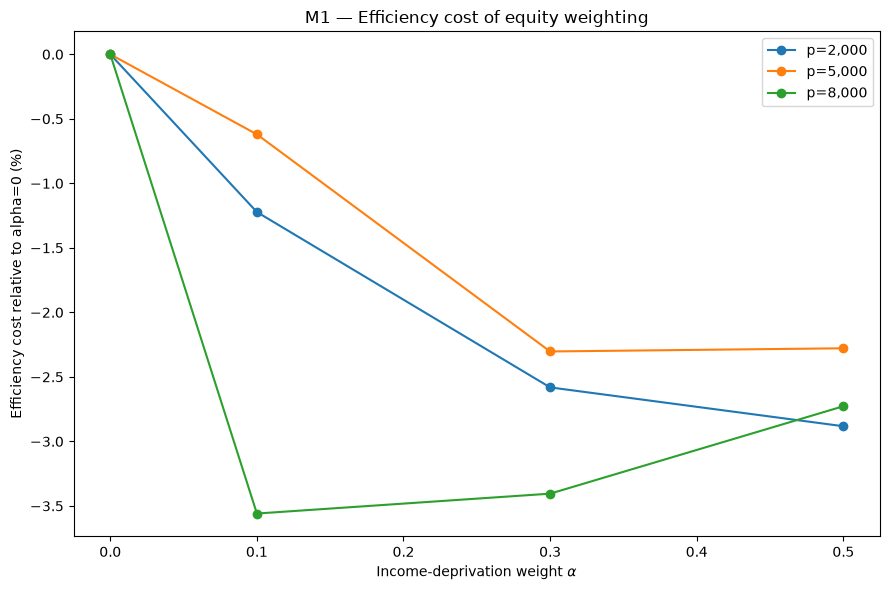

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_M2_tail_accessibility.png


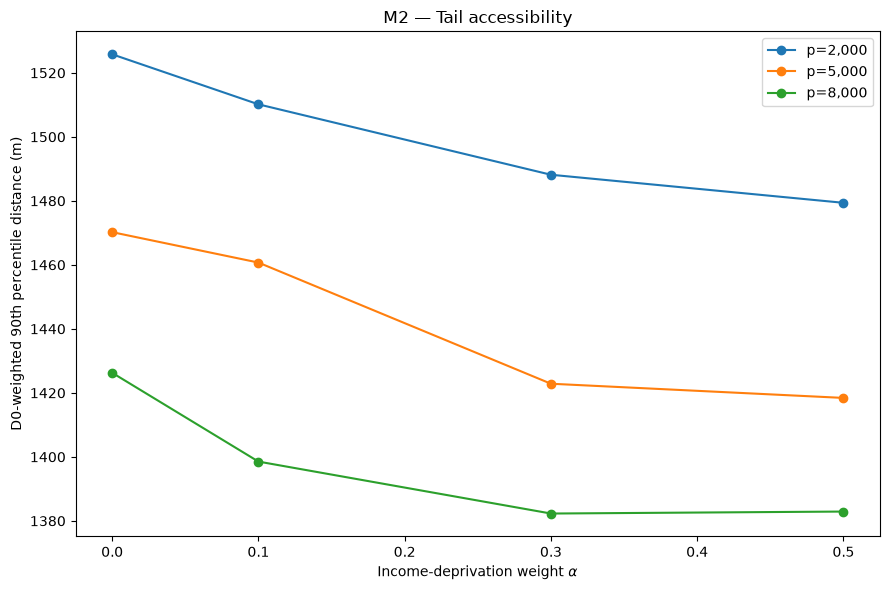

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_M3_deprivation_gap.png


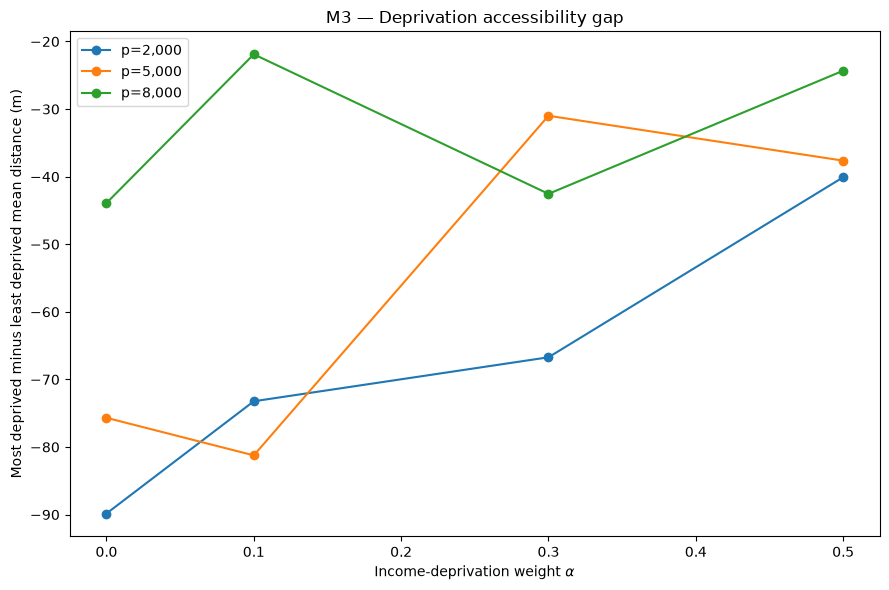

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_M4_equity_allocation_ratio.png


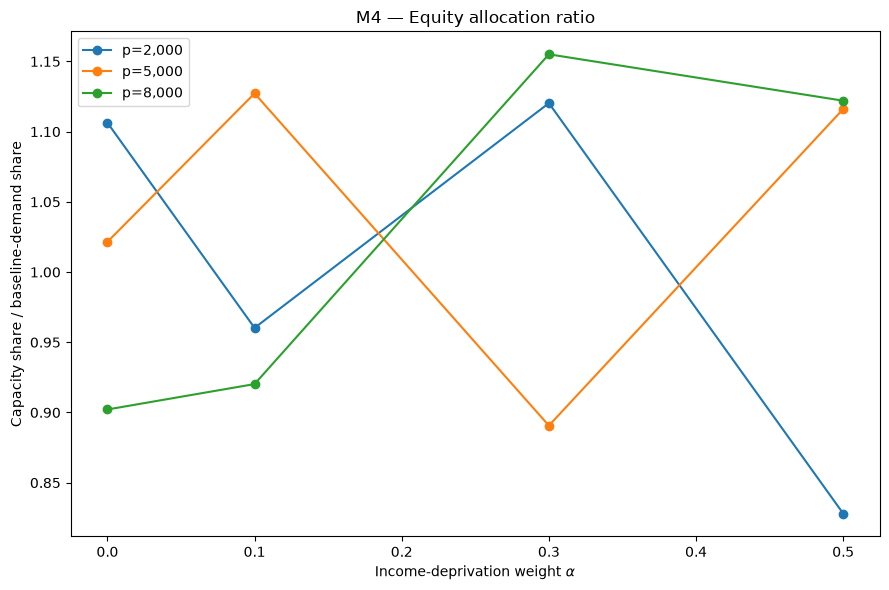

In [21]:
if not core_summary.empty:
    plot_metric_by_alpha(
        core_summary,
        "M1_efficiency_cost_pct",
        "Efficiency cost relative to alpha=0 (%)",
        "M1 — Efficiency cost of equity weighting",
        "fig_M1_efficiency_cost.png",
    )

    plot_metric_by_alpha(
        core_summary,
        "M2_tail_p90_m",
        "D0-weighted 90th percentile distance (m)",
        "M2 — Tail accessibility",
        "fig_M2_tail_accessibility.png",
    )

    plot_metric_by_alpha(
        core_summary,
        "M3_deprivation_accessibility_gap_m",
        "Most deprived minus least deprived mean distance (m)",
        "M3 — Deprivation accessibility gap",
        "fig_M3_deprivation_gap.png",
    )

    plot_metric_by_alpha(
        core_summary,
        "M4_equity_allocation_ratio",
        "Capacity share / baseline-demand share",
        "M4 — Equity allocation ratio",
        "fig_M4_equity_allocation_ratio.png",
    )
else:
    print("M1–M4 figures skipped: run the full core grid first.")


## 9.2 Model-behaviour diagnostics


Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_unmet_demand_share.png


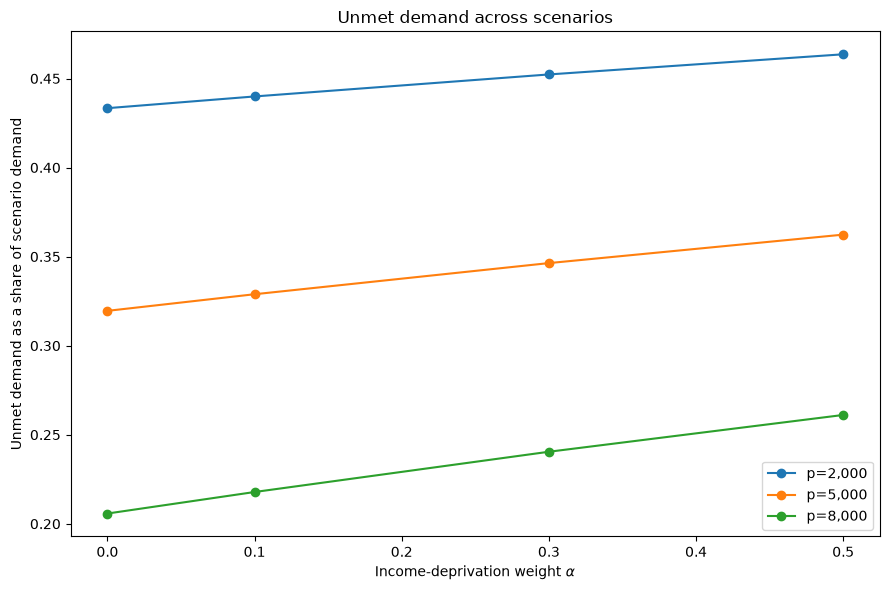

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_own_assignment_share.png


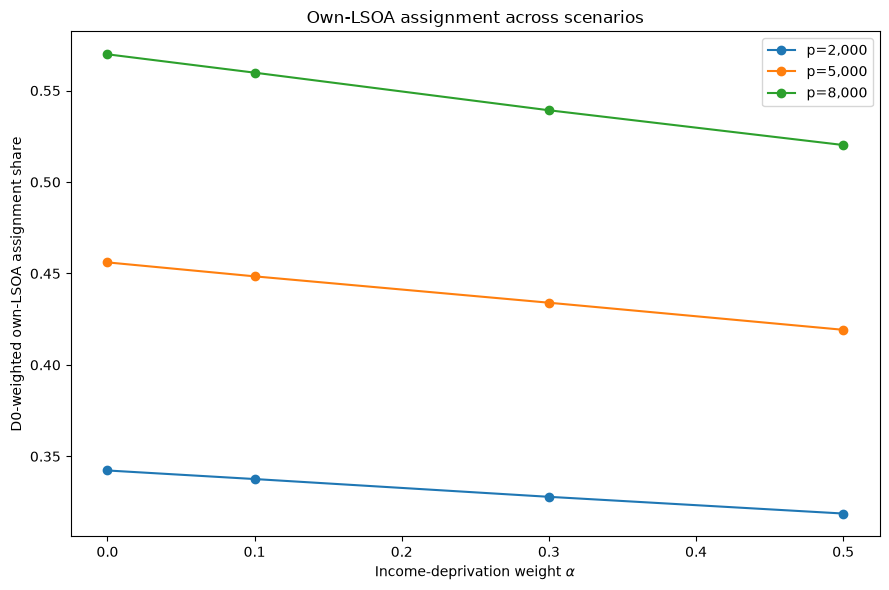

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_absolute_mean_distance.png


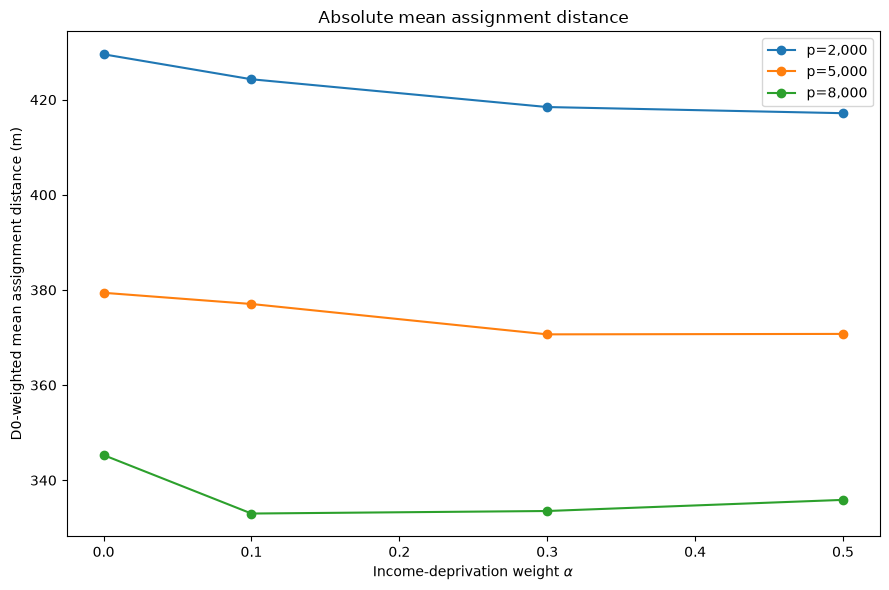

In [22]:
if not core_summary.empty:
    plot_metric_by_alpha(
        core_summary,
        "unmet_demand_share",
        "Unmet demand as a share of scenario demand",
        "Unmet demand across scenarios",
        "fig_unmet_demand_share.png",
    )

    plot_metric_by_alpha(
        core_summary,
        "D0_weighted_own_assignment_share",
        "D0-weighted own-LSOA assignment share",
        "Own-LSOA assignment across scenarios",
        "fig_own_assignment_share.png",
    )

    plot_metric_by_alpha(
        core_summary,
        "absolute_mean_distance_m",
        "D0-weighted mean assignment distance (m)",
        "Absolute mean assignment distance",
        "fig_absolute_mean_distance.png",
    )
else:
    print("Diagnostic figures skipped: run the full core grid first.")


## 9.3 Efficiency–equity trade-off figures


Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_tradeoff_M1_M3.png


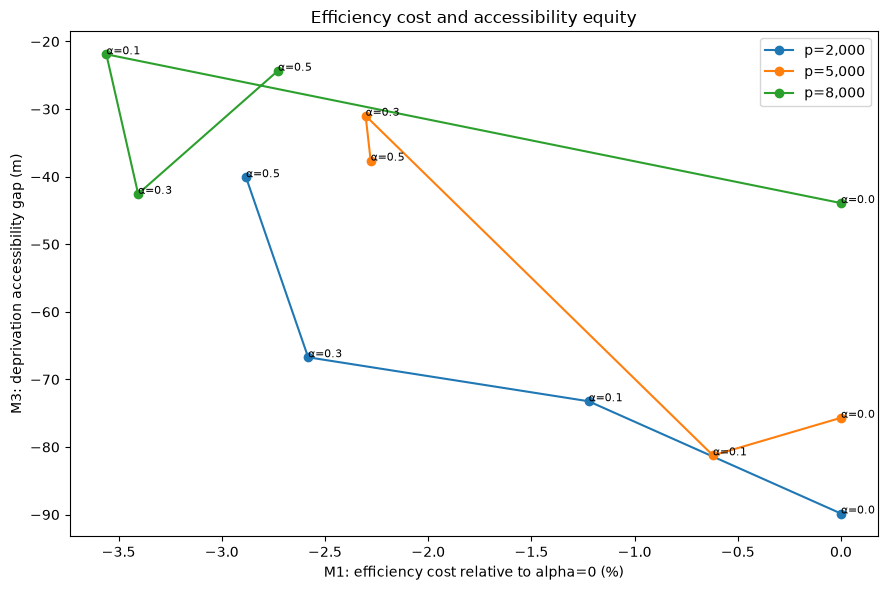

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_tradeoff_M1_M4.png


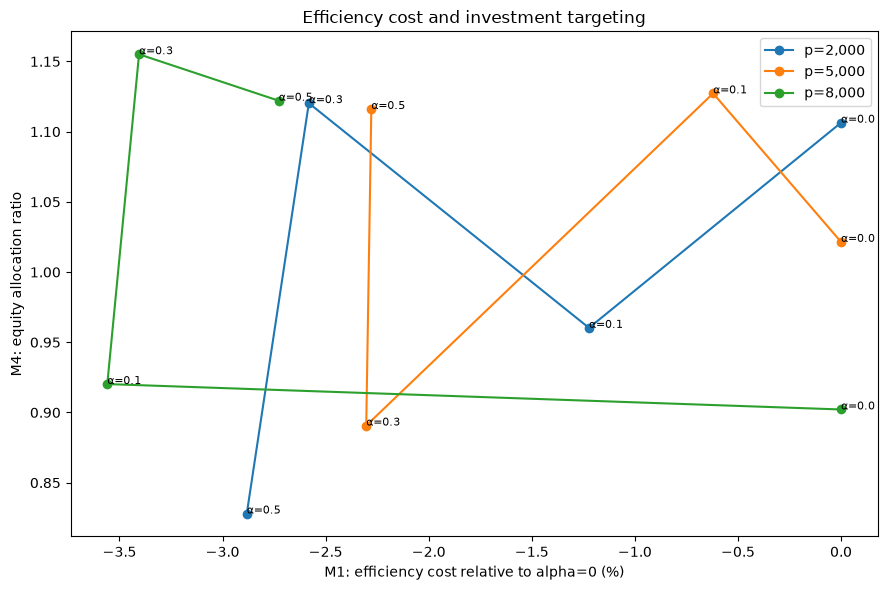

In [23]:
if not core_summary.empty:
    plt.figure(figsize=(9, 6))
    for p in sorted(core_summary["p"].unique()):
        subset = core_summary.loc[core_summary["p"].eq(p)].sort_values("alpha")
        plt.plot(
            subset["M1_efficiency_cost_pct"],
            subset["M3_deprivation_accessibility_gap_m"],
            marker="o",
            label=f"p={p:,}",
        )
        for _, row in subset.iterrows():
            if np.isfinite(row["M1_efficiency_cost_pct"]):
                plt.annotate(
                    f"α={row['alpha']}",
                    (row["M1_efficiency_cost_pct"], row["M3_deprivation_accessibility_gap_m"]),
                    fontsize=8,
                )
    plt.xlabel("M1: efficiency cost relative to alpha=0 (%)")
    plt.ylabel("M3: deprivation accessibility gap (m)")
    plt.title("Efficiency cost and accessibility equity")
    plt.legend()
    save_current_figure("fig_tradeoff_M1_M3.png")

    plt.figure(figsize=(9, 6))
    for p in sorted(core_summary["p"].unique()):
        subset = core_summary.loc[core_summary["p"].eq(p)].sort_values("alpha")
        plt.plot(
            subset["M1_efficiency_cost_pct"],
            subset["M4_equity_allocation_ratio"],
            marker="o",
            label=f"p={p:,}",
        )
        for _, row in subset.iterrows():
            if np.isfinite(row["M1_efficiency_cost_pct"]):
                plt.annotate(
                    f"α={row['alpha']}",
                    (row["M1_efficiency_cost_pct"], row["M4_equity_allocation_ratio"]),
                    fontsize=8,
                )
    plt.xlabel("M1: efficiency cost relative to alpha=0 (%)")
    plt.ylabel("M4: equity allocation ratio")
    plt.title("Efficiency cost and investment targeting")
    plt.legend()
    save_current_figure("fig_tradeoff_M1_M4.png")
else:
    print("Trade-off figures skipped: run the full core grid first.")


## 9.4 Deprivation-decile profiles


Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_decile_distance_profiles_p5000.png


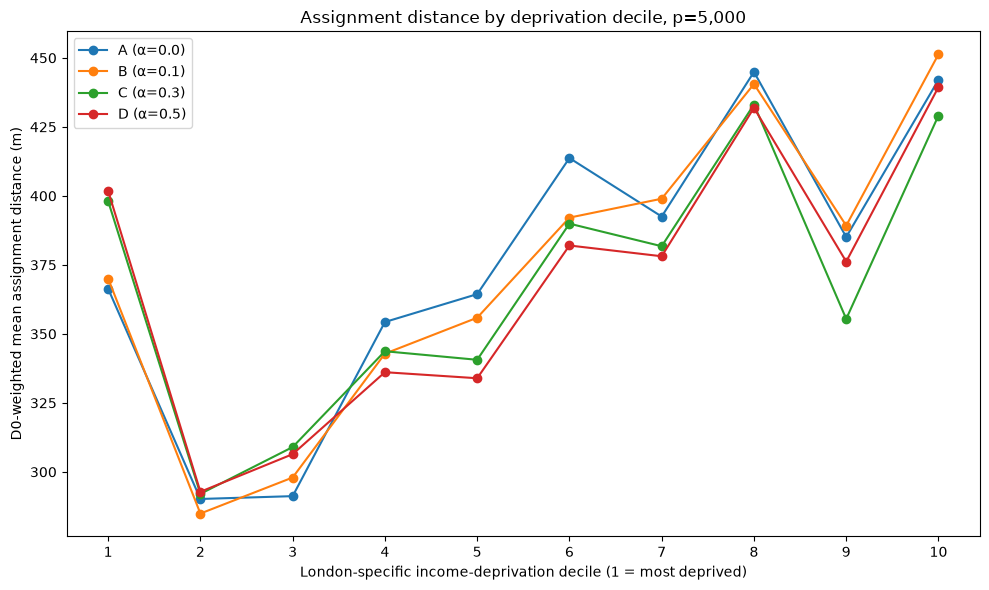

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/fig_decile_capacity_profiles_p5000.png


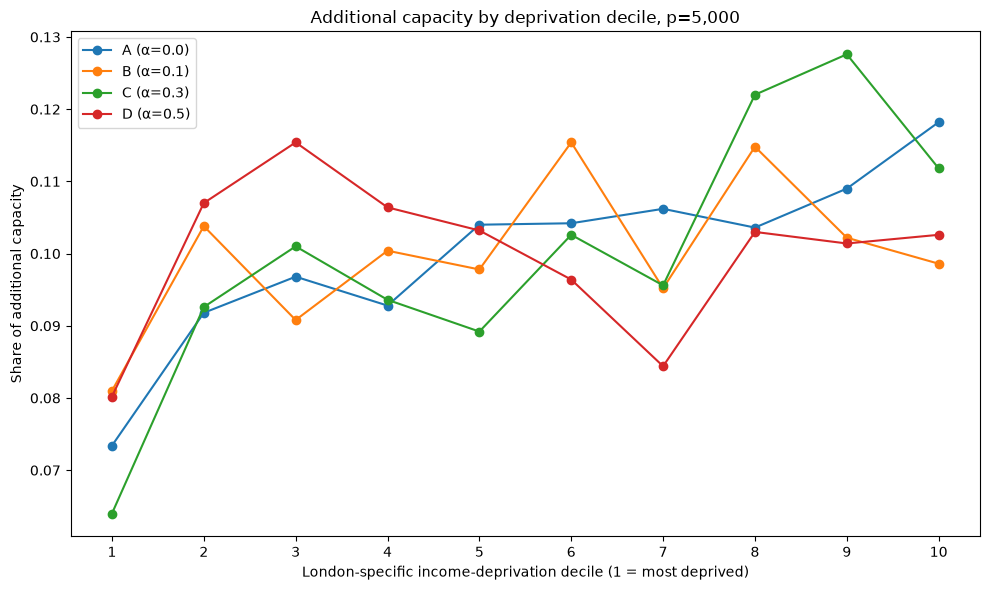

In [24]:
def build_decile_profiles(
    results: dict[tuple[str, int], dict],
    p: int,
) -> pd.DataFrame:
    rows: list[dict] = []
    deciles = lsoa_master["london_income_decile"].to_numpy(dtype=int)

    for scenario_label in SCENARIOS:
        key = (scenario_label, p)
        if key not in results:
            continue
        result = results[key]
        dbar = np.asarray(result["dbar_i_served"], dtype=float)
        x_values = np.asarray(result["x_j"], dtype=float)

        for decile in range(1, 11):
            mask = deciles == decile
            rows.append({
                "scenario": scenario_label,
                "alpha": SCENARIOS[scenario_label]["alpha"],
                "p": p,
                "decile": decile,
                "mean_distance_m": weighted_mean(dbar[mask], D0[mask]),
                "capacity_units": float(x_values[mask].sum()),
                "capacity_share": float(x_values[mask].sum() / p),
                "baseline_demand_share": float(D0[mask].sum() / D0.sum()),
            })
    return pd.DataFrame(rows)


if core_results and all((scenario, P_REF) in core_results for scenario in SCENARIOS):
    decile_profiles = build_decile_profiles(core_results, P_REF)
    decile_profiles.to_csv(TABLES_DIR / "decile_profiles_p5000.csv", index=False)

    plt.figure(figsize=(10, 6))
    for scenario_label in SCENARIOS:
        subset = decile_profiles.loc[decile_profiles["scenario"].eq(scenario_label)]
        plt.plot(
            subset["decile"], subset["mean_distance_m"], marker="o",
            label=f"{scenario_label} (α={SCENARIOS[scenario_label]['alpha']})",
        )
    plt.xlabel("London-specific income-deprivation decile (1 = most deprived)")
    plt.ylabel("D0-weighted mean assignment distance (m)")
    plt.title(f"Assignment distance by deprivation decile, p={P_REF:,}")
    plt.xticks(range(1, 11))
    plt.legend()
    save_current_figure("fig_decile_distance_profiles_p5000.png")

    plt.figure(figsize=(10, 6))
    for scenario_label in SCENARIOS:
        subset = decile_profiles.loc[decile_profiles["scenario"].eq(scenario_label)]
        plt.plot(
            subset["decile"], subset["capacity_share"], marker="o",
            label=f"{scenario_label} (α={SCENARIOS[scenario_label]['alpha']})",
        )
    plt.xlabel("London-specific income-deprivation decile (1 = most deprived)")
    plt.ylabel("Share of additional capacity")
    plt.title(f"Additional capacity by deprivation decile, p={P_REF:,}")
    plt.xticks(range(1, 11))
    plt.legend()
    save_current_figure("fig_decile_capacity_profiles_p5000.png")
else:
    decile_profiles = pd.DataFrame()
    print("Decile profiles skipped: all four reference-p scenarios are required.")


## 9.5 Allocation maps and change maps


Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_x_A_p5000.png


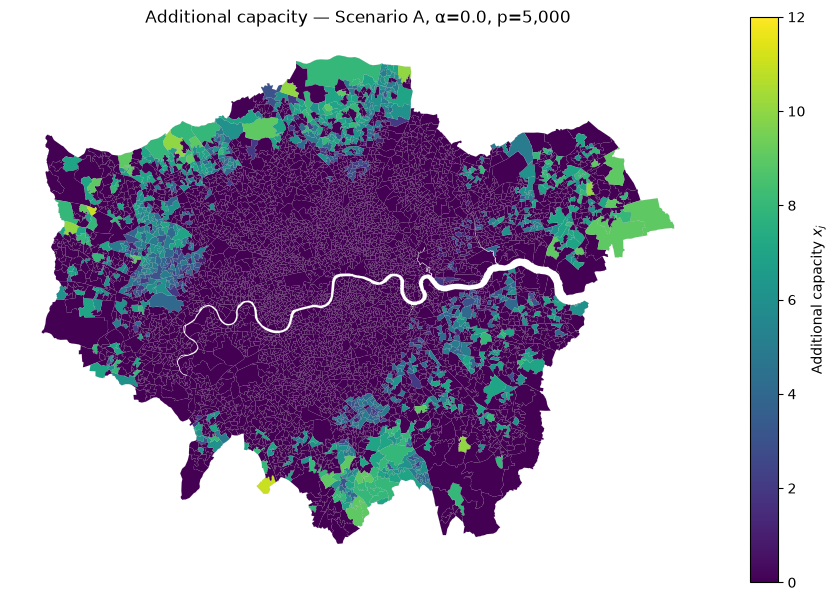

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_x_B_p5000.png


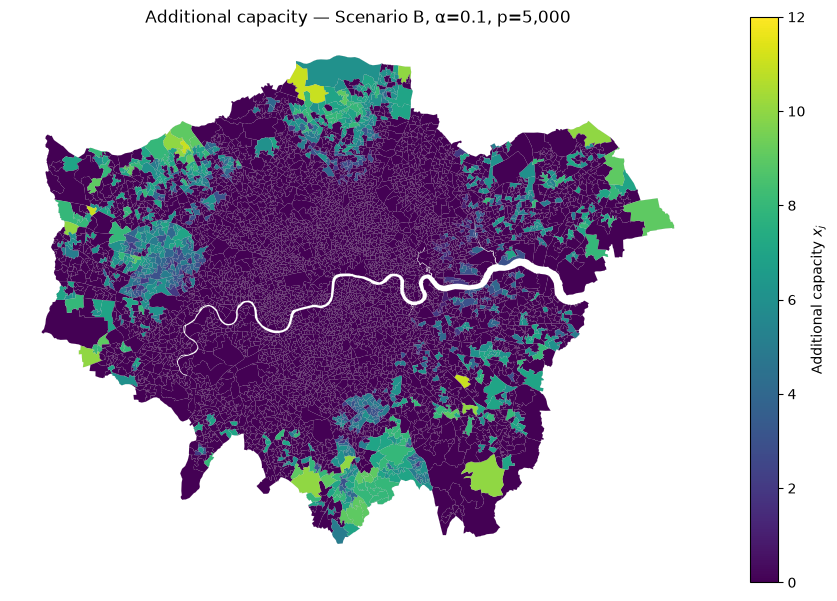

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_x_C_p5000.png


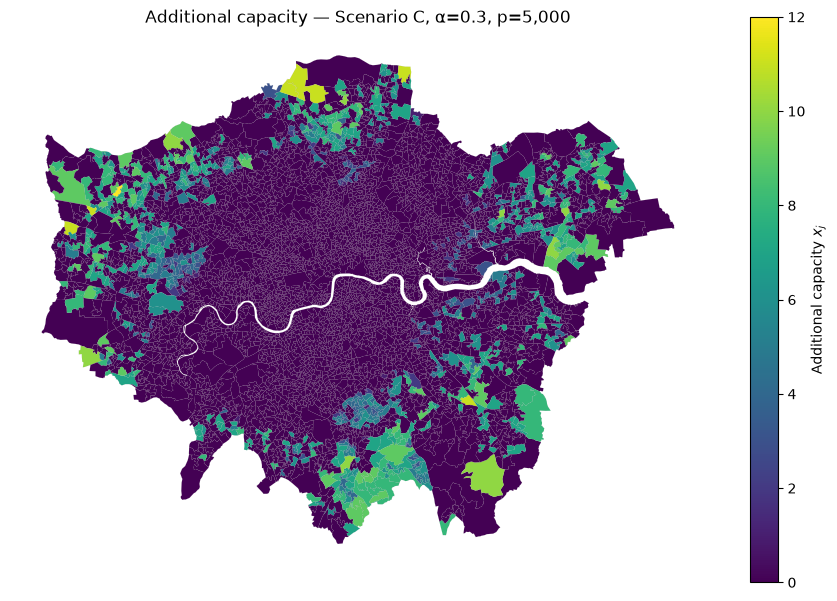

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_x_D_p5000.png


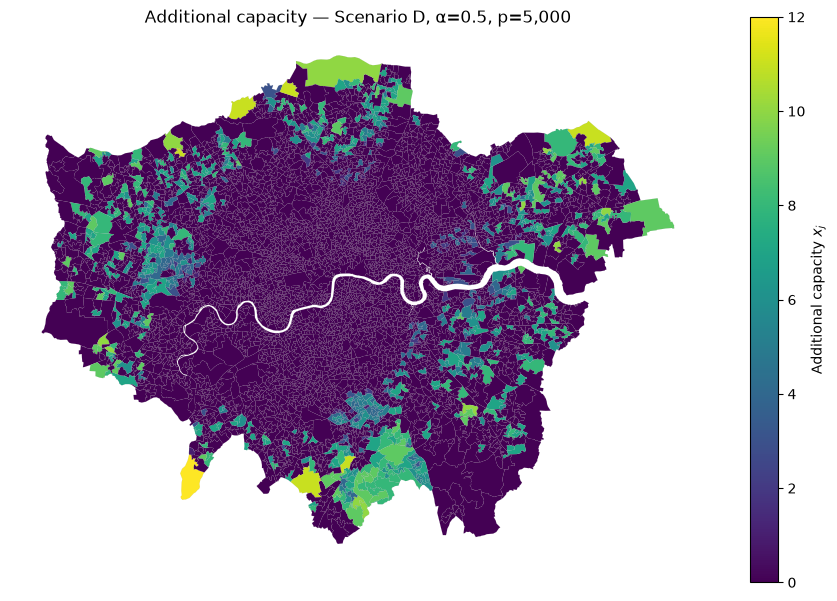

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_delta_x_B_minus_A_p5000.png


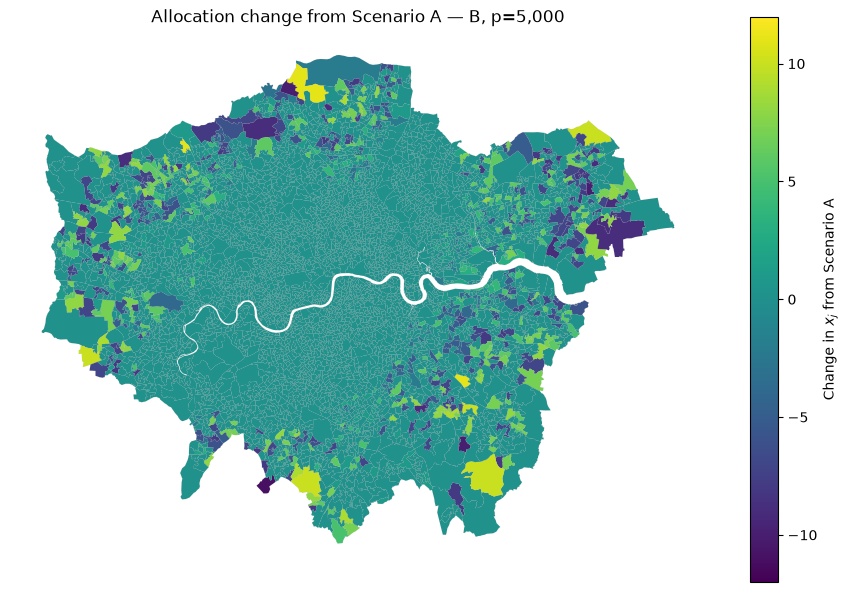

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_delta_x_C_minus_A_p5000.png


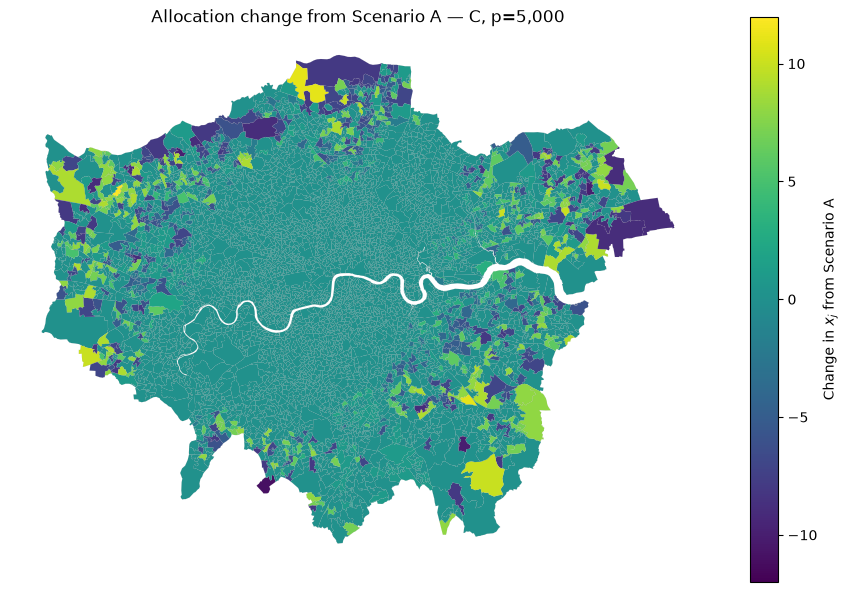

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_delta_x_D_minus_A_p5000.png


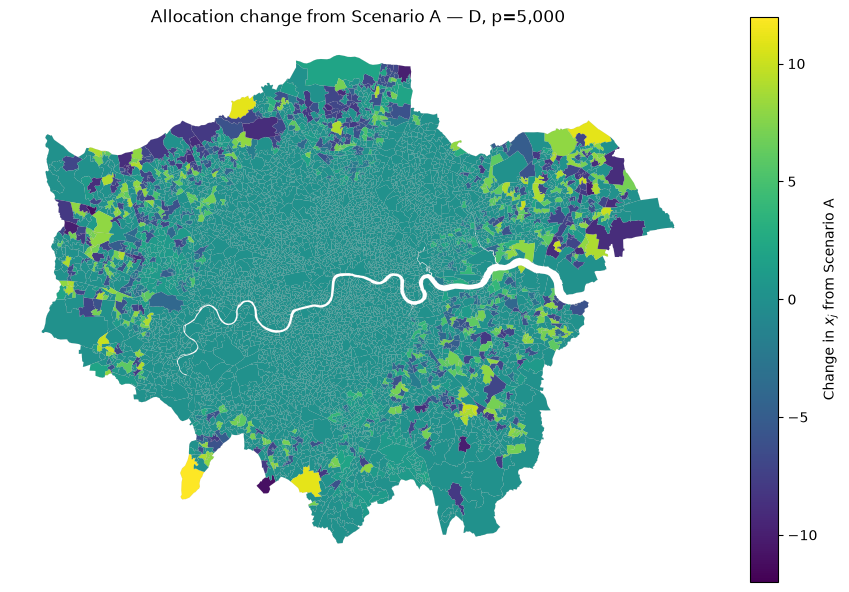

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_dbar_A_p5000.png


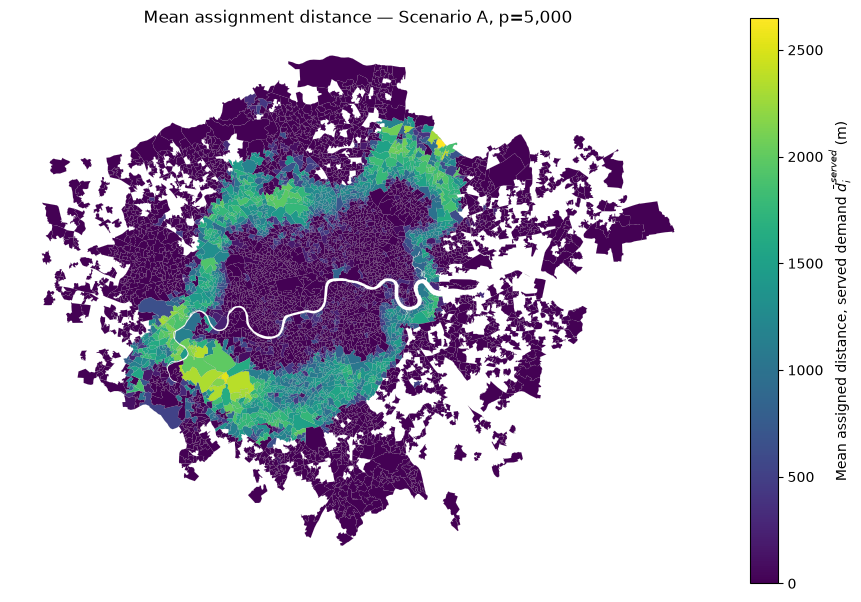

Saved: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/05_p_median/map_dbar_C_p5000.png


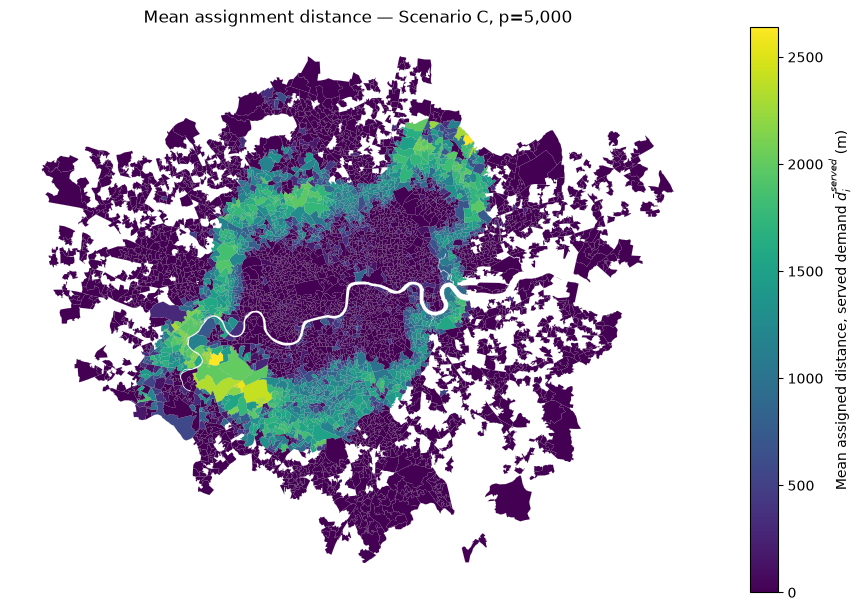

In [25]:
def base_map_frame() -> gpd.GeoDataFrame:
    return (
        lsoa_geometry[["lsoa_code", "geometry"]]
        .merge(lsoa_master[["lsoa_code"]], on="lsoa_code", how="inner", validate="one_to_one")
        .sort_values("lsoa_code")
        .reset_index(drop=True)
    )


if core_results and all((scenario, P_REF) in core_results for scenario in SCENARIOS):
    map_base = base_map_frame()
    shared_x_vmax = max(core_results[(scenario, P_REF)]["x_j"].max() for scenario in SCENARIOS)

    for scenario_label in SCENARIOS:
        plot_data = map_base.copy()
        plot_data["x_j"] = core_results[(scenario_label, P_REF)]["x_j"]
        plt.figure(figsize=(9, 9))
        ax = plt.gca()
        plot_data.plot(
            column="x_j", ax=ax, vmin=0, vmax=shared_x_vmax,
            linewidth=0.05, edgecolor="grey", legend=True,
            legend_kwds={"label": r"Additional capacity $x_j$", "shrink": 0.65},
        )
        ax.set_title(
            f"Additional capacity — Scenario {scenario_label}, "
            f"α={SCENARIOS[scenario_label]['alpha']}, p={P_REF:,}"
        )
        ax.axis("off")
        save_current_figure(f"map_x_{scenario_label}_p{P_REF}.png")

    baseline_x = core_results[("A", P_REF)]["x_j"]
    shared_abs_change = max(
        np.abs(core_results[(scenario, P_REF)]["x_j"] - baseline_x).max()
        for scenario in ["B", "C", "D"]
    )

    for scenario_label in ["B", "C", "D"]:
        plot_data = map_base.copy()
        plot_data["delta_x"] = core_results[(scenario_label, P_REF)]["x_j"] - baseline_x
        plt.figure(figsize=(9, 9))
        ax = plt.gca()
        plot_data.plot(
            column="delta_x", ax=ax,
            vmin=-shared_abs_change, vmax=shared_abs_change,
            linewidth=0.05, edgecolor="grey", legend=True,
            legend_kwds={"label": r"Change in $x_j$ from Scenario A", "shrink": 0.65},
        )
        ax.set_title(
            f"Allocation change from Scenario A — {scenario_label}, p={P_REF:,}"
        )
        ax.axis("off")
        save_current_figure(f"map_delta_x_{scenario_label}_minus_A_p{P_REF}.png")

    for scenario_label in ["A", REFERENCE_SCENARIO]:
        plot_data = map_base.copy()
        plot_data["dbar_i_served"] = core_results[(scenario_label, P_REF)]["dbar_i_served"]
        plt.figure(figsize=(9, 9))
        ax = plt.gca()
        plot_data.plot(
            column="dbar_i_served", ax=ax,
            linewidth=0.05, edgecolor="grey", legend=True,
            legend_kwds={"label": r"Mean assigned distance, served demand $\bar d_i^{served}$ (m)", "shrink": 0.65},
        )
        ax.set_title(
            f"Mean assignment distance — Scenario {scenario_label}, p={P_REF:,}"
        )
        ax.axis("off")
        save_current_figure(f"map_dbar_{scenario_label}_p{P_REF}.png")
else:
    print("Maps skipped: all four reference-p scenarios are required.")


## 9.6 Scenario-change and top-allocation tables


In [26]:
if core_results:
    change_rows: list[dict] = []
    for p in P_VALUES:
        baseline_key = ("A", p)
        if baseline_key not in core_results:
            continue
        baseline_x = core_results[baseline_key]["x_j"]
        baseline_dbar = core_results[baseline_key]["dbar_i_served"]

        for scenario_label in ["B", "C", "D"]:
            key = (scenario_label, p)
            if key not in core_results:
                continue
            x_values = core_results[key]["x_j"]
            dbar = core_results[key]["dbar_i_served"]
            correlation = spearmanr(baseline_x, x_values).statistic
            change_rows.append({
                "scenario": scenario_label,
                "alpha": SCENARIOS[scenario_label]["alpha"],
                "p": p,
                "L1_change_in_x_j": float(np.abs(x_values - baseline_x).sum()),
                "n_lsoas_gaining_capacity": int((x_values > baseline_x).sum()),
                "n_lsoas_losing_capacity": int((x_values < baseline_x).sum()),
                "spearman_x_vs_baseline": float(correlation),
                "total_absolute_change_in_dbar_m": float(
                    np.nansum(np.abs(dbar - baseline_dbar))
                ),
            })

    scenario_change_summary = pd.DataFrame(change_rows)
    scenario_change_summary.to_csv(
        TABLES_DIR / "scenario_change_from_baseline.csv", index=False
    )
    print("\n=== Change from Scenario A ===")
    print(scenario_change_summary.to_string(index=False))

    top_rows: list[pd.DataFrame] = []
    for scenario_label in SCENARIOS:
        key = (scenario_label, P_REF)
        if key not in core_results:
            continue
        table = lsoa_master[[
            "lsoa_code", "e_i", "D_A", "IMD_i", "london_income_decile",
        ]].copy()
        table["scenario"] = scenario_label
        table["alpha"] = SCENARIOS[scenario_label]["alpha"]
        table["p"] = P_REF
        table["x_j"] = core_results[key]["x_j"]
        table["z_i"] = core_results[key]["z_i"]
        table["dbar_i_served"] = core_results[key]["dbar_i_served"]
        top_rows.append(table.nlargest(20, "x_j"))

    if top_rows:
        top_allocations = pd.concat(top_rows, ignore_index=True)
        top_allocations.to_csv(TABLES_DIR / "top_20_allocations_by_scenario.csv", index=False)
        print("\n=== Top 20 allocations by reference-p scenario ===")
        print(top_allocations.to_string(index=False))
else:
    scenario_change_summary = pd.DataFrame()
    top_allocations = pd.DataFrame()
    print("Scenario-change tables skipped: run the full grid first.")



=== Change from Scenario A ===
scenario  alpha    p  L1_change_in_x_j  n_lsoas_gaining_capacity  n_lsoas_losing_capacity  spearman_x_vs_baseline  total_absolute_change_in_dbar_m
       B    0.1 2000       2448.000000                       251                      230                0.336496                    108155.310563
       C    0.3 2000       2650.000000                       263                      256                0.290782                    224956.300950
       D    0.5 2000       2754.000000                       294                      257                0.281023                    318531.723789
       B    0.1 5000       4330.000000                       480                      386                0.483334                    113898.747760
       C    0.3 5000       4946.000000                       611                      459                0.431898                    233518.333201
       D    0.5 5000       5312.000000                       720                      

## 9.7 Extended investment-sensitivity figures


In [17]:
if not extended_p_summary.empty:
    for metric, ylabel, title, filename in [
        ("absolute_mean_distance_m", "D0-weighted mean distance (m)",
         "Mean assignment distance across investment levels", "fig_extended_p_mean_distance.png"),
        ("unmet_demand_share", "Unmet demand share of scenario demand",
         "Unmet demand across investment levels", "fig_extended_p_unmet_demand.png"),
        ("M3_deprivation_accessibility_gap_m", "Deprivation accessibility gap (m)",
         "Accessibility equity across investment levels", "fig_extended_p_M3.png"),
        ("M4_equity_allocation_ratio", "Equity allocation ratio",
         "Investment targeting across investment levels", "fig_extended_p_M4.png"),
    ]:
        plt.figure(figsize=(9, 6))
        for scenario_label in EXTENDED_P_SCENARIOS:
            subset = extended_p_summary.loc[
                extended_p_summary["scenario"].eq(scenario_label)
            ].sort_values("p")
            plt.plot(
                subset["p"], subset[metric], marker="o",
                label=f"{scenario_label} (α={SCENARIOS[scenario_label]['alpha']})",
            )
        plt.xlabel("Total additional capacity p")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        save_current_figure(filename)
else:
    print("Extended-p figures skipped: enable RUN_EXTENDED_P_SENSITIVITY.")


Extended-p figures skipped: enable RUN_EXTENDED_P_SENSITIVITY.


## 10. Interpretation and reporting rules

1. Report the CBC solver status, runtime, and any available optimality gap for **both** Step 1
   and Step 2 of every model run.
2. `Optimal` certifies optimality only for the **sparse MILP actually formulated** using the
   selected \(k\), \(K\), \(U_j\), and service-radius setting -- for both steps.
3. Use `distance_objective` and \(\bar d_i^{served}\) for M1–M3; these already reflect only
   genuinely served demand, so no separate "penalised objective" exists to guard against.
4. Report \(z_i\) (unmet demand) and `unmet_demand_share` as model diagnostics. When non-zero,
   state that the capacity constraints could not absorb all recognised demand under that
   scenario, and consider reporting `unmet_share_most/least_deprived_decile` alongside M3/M4.
5. If the baseline mean *served* distance is zero or undefined (NaN, i.e. `z_i=1` for the whole
   baseline) at a given \(p\), M1 is mathematically undefined at that \(p\). Do not force it to
   zero.
6. A high own-LSOA assignment share may reflect generous local capacity rather than a coding
   error. Interpret it together with `unmet_demand_share`, \(p\), and the number of LSOAs
   receiving \(x_j>0\).
7. The difference maps, deprivation-decile profiles, and M1–M4 plots are the main outputs for
   the Results chapter. Parameter sensitivity and unmet-demand diagnostics are more appropriate
   for the Discussion, limitations, or appendix.
